In [1]:
import os
import tensorflow

from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping
from tensorflow.keras.preprocessing import image

# 수강생 배포 파일 이름 : 수강생배포_dogvscat_data.zip
rootPath = 'E:/AIWork/Data/dogvscat/'

# ImageDataGenerator는 이미지 데이터를 모델에 넣기 전에
# 전처리와 데이터 증강을 자동으로 수행해 주는 도구입니다.
#
# 여기서는 학습 이미지의 픽셀값을 0~1 사이로 정규화하고,
# 회전, 이동, 밝기 변경, 좌우 반전 같은 변형을 적용합니다.
#
# 이렇게 하면 원본 이미지 수가 많지 않아도
# 모델이 다양한 형태의 이미지를 학습하는 효과를 얻을 수 있습니다.
#
# 또한 validation_split=0.2를 사용하여
# train 폴더 안의 이미지 중 20%를 검증용 데이터로 분리합니다.
imageGenerator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    validation_split=0.2,
    fill_mode='nearest'
)

# flow_from_directory()는 폴더 구조를 기준으로
# 이미지를 자동으로 읽어오고 라벨을 붙여주는 함수입니다.
#
# 예를 들어 폴더 구조가 아래와 같다면,
#
# train/
# ├── cats/
# └── dogs/
#
# cats 폴더의 이미지는 한 클래스,
# dogs 폴더의 이미지는 다른 클래스로 자동 분류됩니다.
#
# subset='training'은 ImageDataGenerator에서 설정한
# validation_split=0.2를 기준으로,
# 전체 데이터 중 80%를 학습용 데이터로 사용하겠다는 의미입니다.
trainGen = imageGenerator.flow_from_directory(
    os.path.join(rootPath, 'train'),
    target_size=(128, 128),
     class_mode='binary',
    subset='training'
)

# validationGen은 모델 학습 중 성능을 확인하기 위한 검증 데이터입니다.
#
# 학습 데이터(trainGen)는 모델의 가중치를 업데이트하는 데 사용되고,
# 검증 데이터(validationGen)는 학습 중 모델이 새로운 데이터에도
# 잘 맞는지 확인하는 데 사용됩니다.
#
# subset='validation'은 ImageDataGenerator에서 설정한
# validation_split=0.2를 기준으로,
# 전체 데이터 중 20%를 검증용 데이터로 사용하겠다는 의미입니다.
#
# 주의할 점:
# trainGen과 validationGen은 같은 train 폴더에서 데이터를 가져오지만,
# subset 값이 다르기 때문에 서로 다른 이미지 묶음을 사용합니다.
validationGen = imageGenerator.flow_from_directory(
    os.path.join(rootPath, 'train'),
    target_size=(128, 128),
     class_mode='binary',
    subset='validation'
)

print(trainGen.samples)

Found 1600 images belonging to 2 classes.
Found 400 images belonging to 2 classes.
1600


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers, models, Input

# 128x128 크기의 컬러 이미지를 입력받는 CNN 이진 분류 모델입니다.
# Conv2D와 MaxPooling2D로 이미지의 특징을 추출하고, Flatten으로 1차원 형태로 변환합니다.
# Dense와 Dropout을 거쳐 최종적으로 sigmoid 출력층에서 0 또는 1에 가까운 확률을 예측합니다.
# 수강생 작성(model 정의)

model.summary()

trainGen.samples

# model.compile 코드 작성
# 수강생 작성(model 정의)

# 모델 최적화 설정 - ModelCheckpoint, EarlyStopping
# filepath="Model_CNN_Gen.keras" 사용
# 수강생 작성

epochs = 32
history = model.fit(
    trainGen, 
    epochs=epochs,
    steps_per_epoch = trainGen.samples // trainGen.batch_size, 
    validation_data=validationGen,
    validation_steps = validationGen.samples // validationGen.batch_size,
    callbacks=[early_stopping_callback,checkpointer]
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 127008)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      65,028,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 65,030,017 (248.07 MB)

 Trainable params: 65,030,017 (248.07 MB)

 Non-trainable params: 0 (0.00 B)

C:\Users\fasof\.conda\envs\tf219\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/32
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.7337 - loss: 3.2226 
Epoch 1: val_loss improved from inf to 0.05632, saving model to Model_CNN_Gen.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 521ms/step - accuracy: 0.7364 - loss: 3.1848 - val_accuracy: 0.9766 - val_loss: 0.0563
Epoch 2/32
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.9887 - loss: 0.0307 
Epoch 2: val_loss improved from 0.05632 to 0.04168, saving model to Model_CNN_Gen.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 25s 505ms/step - accuracy: 0.9886 - loss: 0.0308 - val_accuracy: 0.9844 - val_loss: 0.0417
Epoch 3/32
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.9917 - loss: 0.0341 
Epoch 3: val_loss improved from 0.04168 to 0.01854, saving model to Model_CNN_Gen.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 25s 496ms/step - accuracy: 0.9917 - loss: 0.0339 - val_accuracy: 0.9922 - val_loss: 0.0185
Epoch 4/32
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.9945 - loss: 0.0162 
Epoch 4: val_loss did not improve from

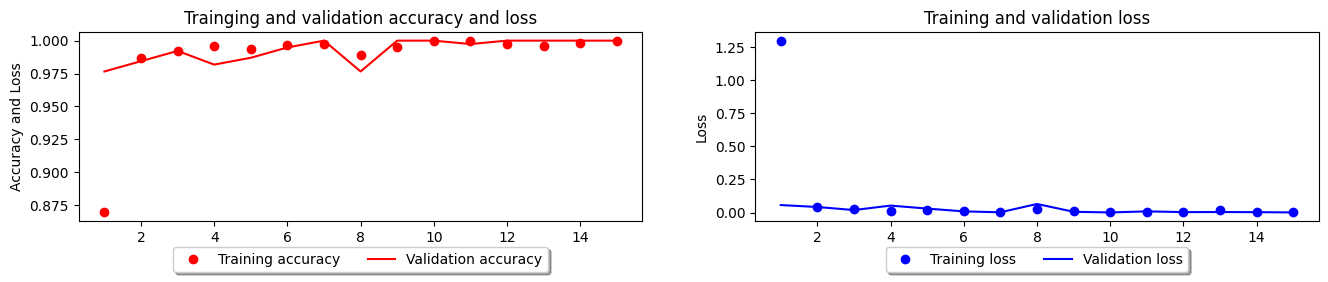

In [4]:
import matplotlib.pyplot as plt
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.figure(figsize=(16, 1))

plt.subplot(121)
plt.subplots_adjust(top=2)
plt.plot(epochs, accuracy, 'ro', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'r', label='Validation accuracy')
plt.title('Trainging and validation accuracy and loss')
plt.xlabel('Epochs')
plt.ylabel('Accuracy and Loss')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
          fancybox=True, shadow=True, ncol=5)
plt.subplot(122)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
      fancybox=True, shadow=True, ncol=5)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


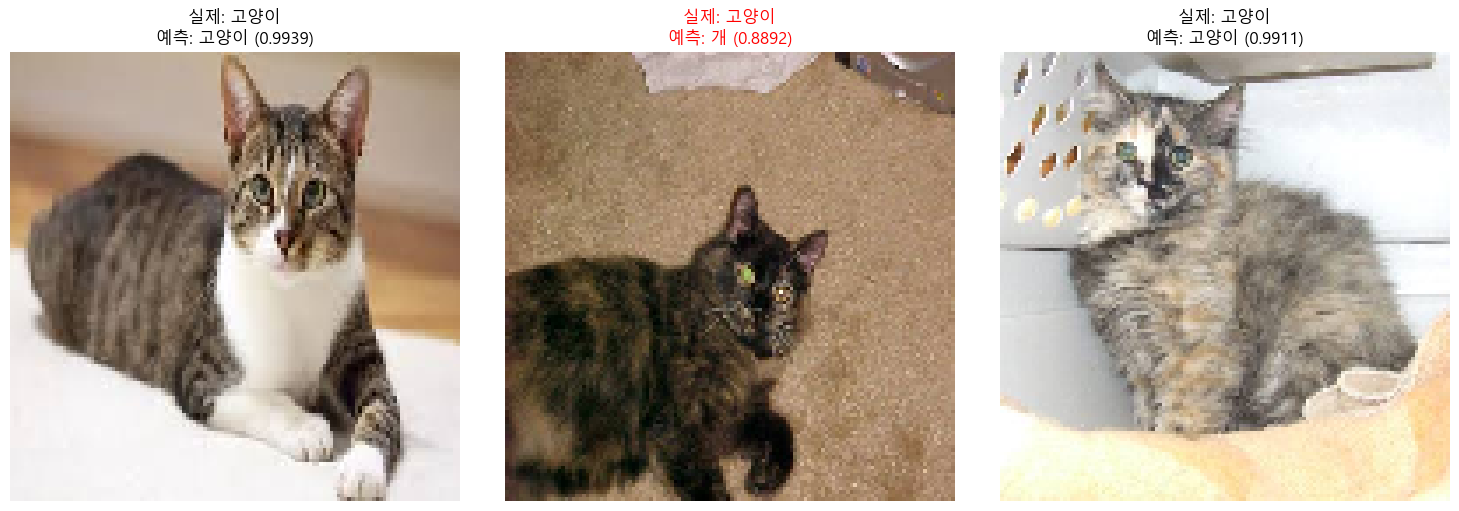

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


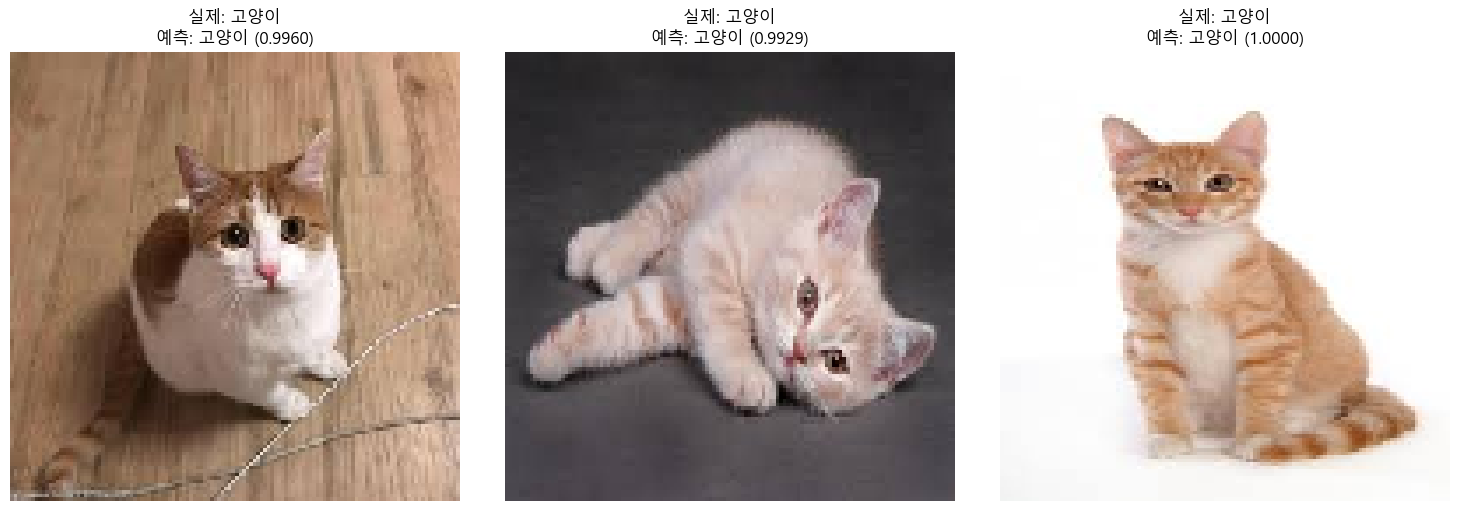

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


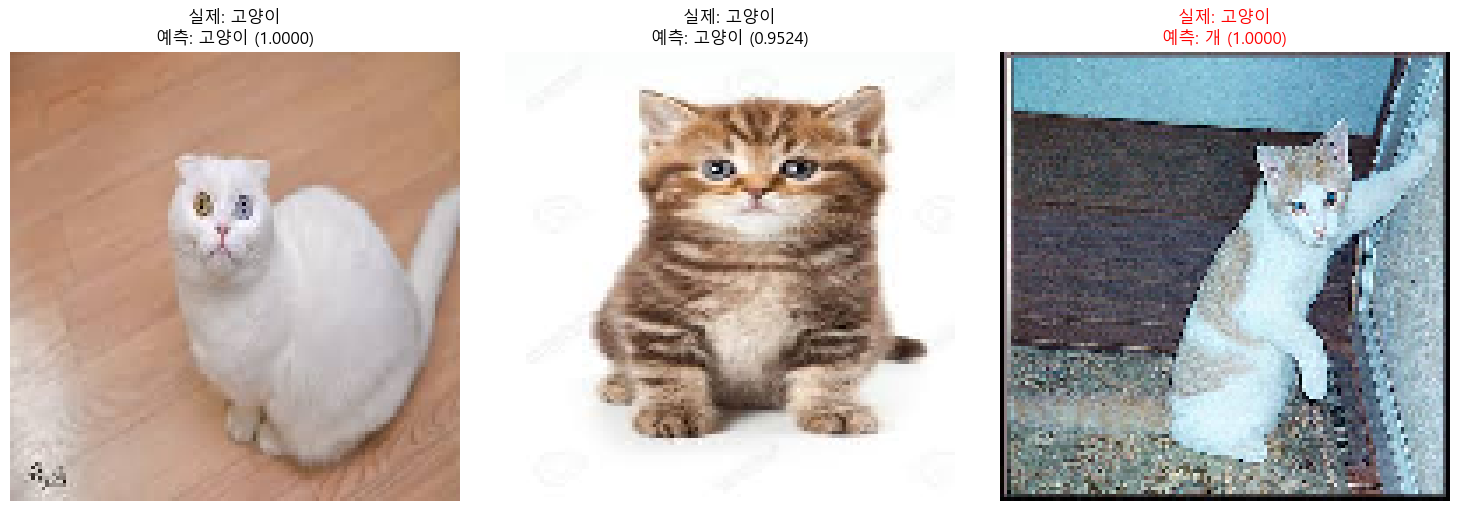

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


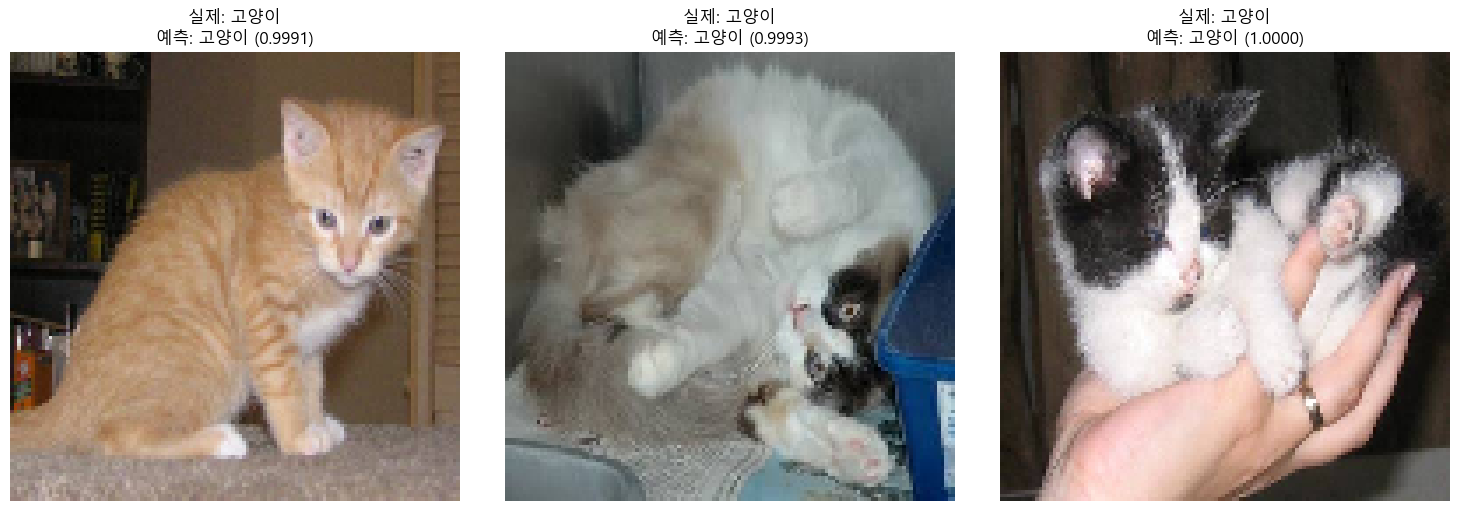

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


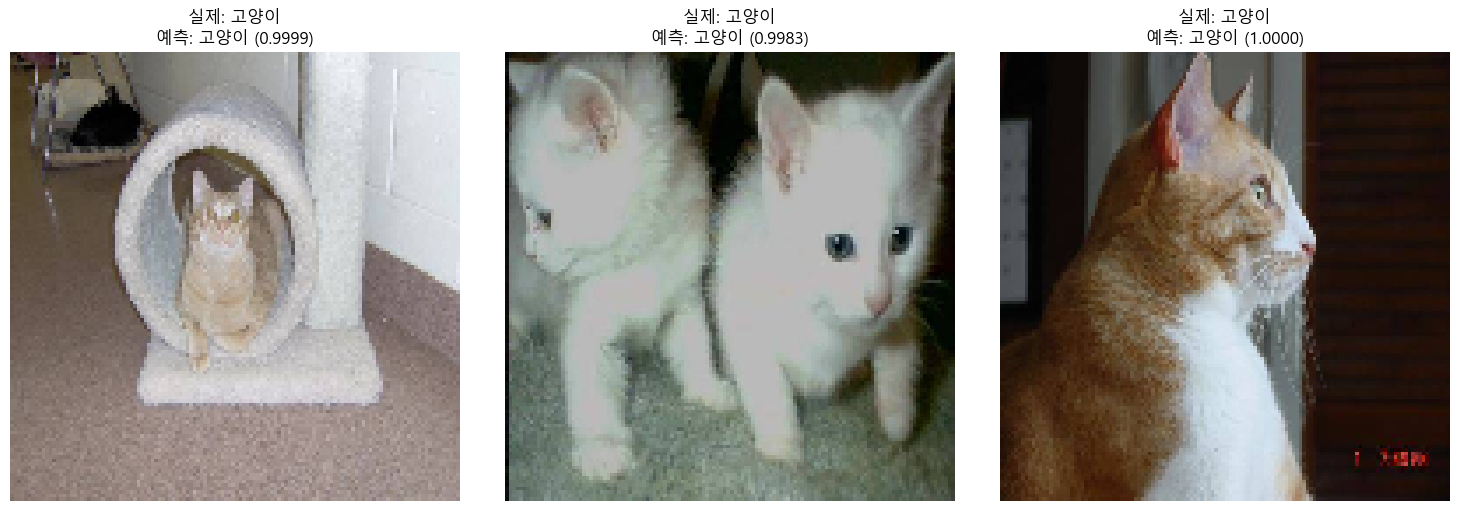

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


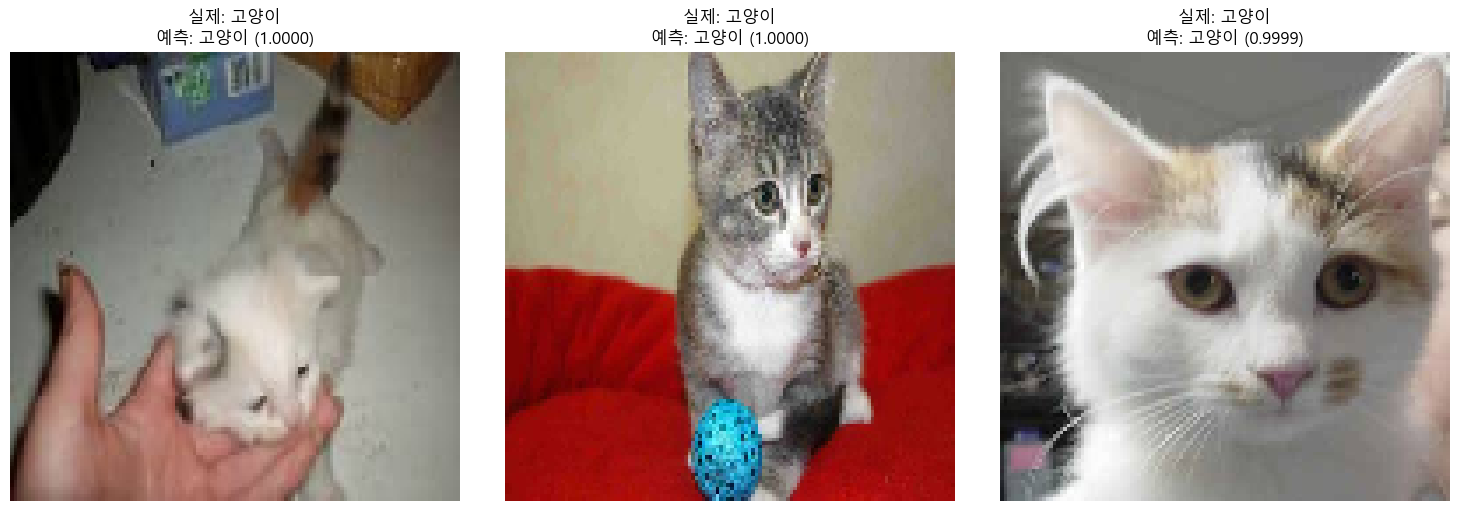

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


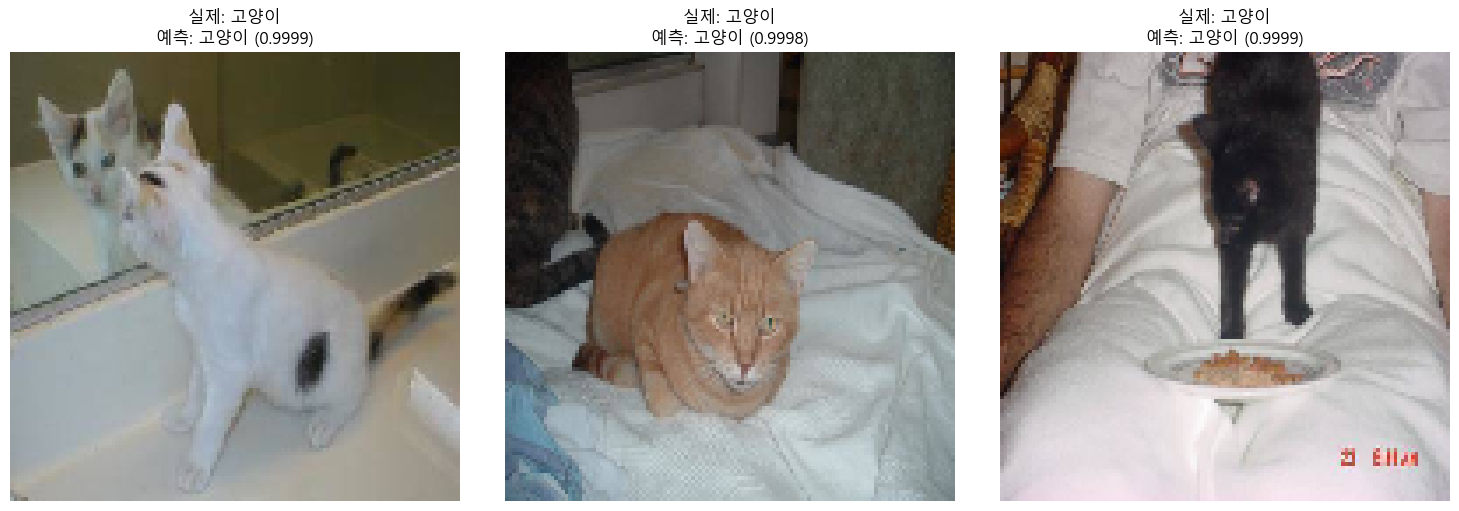

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


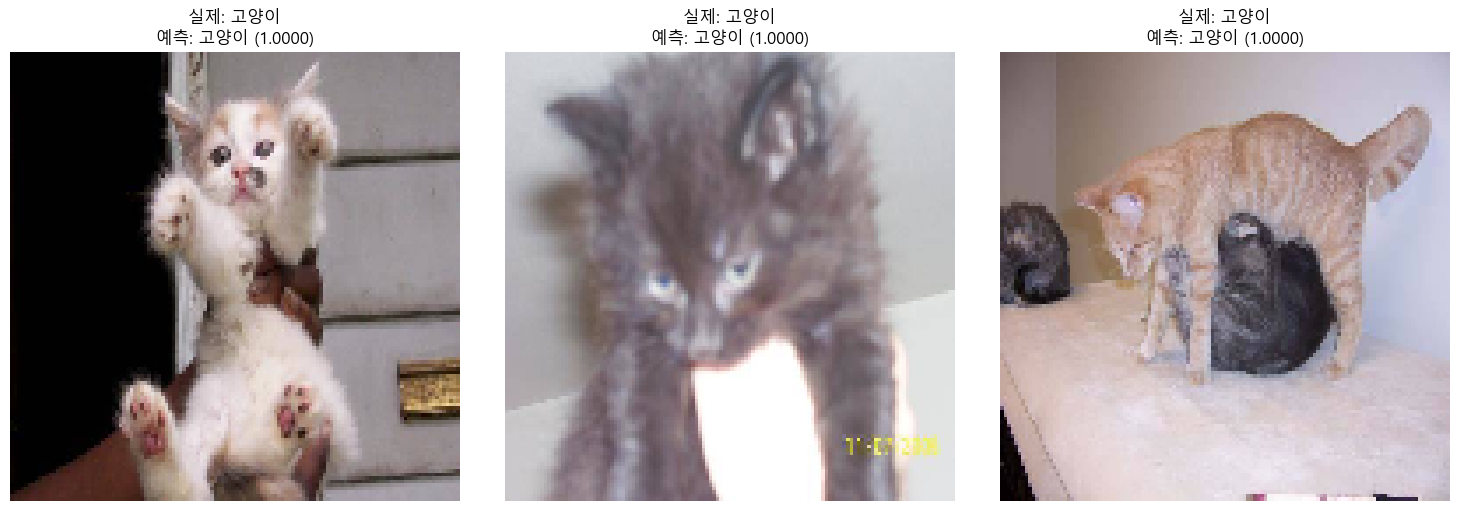

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


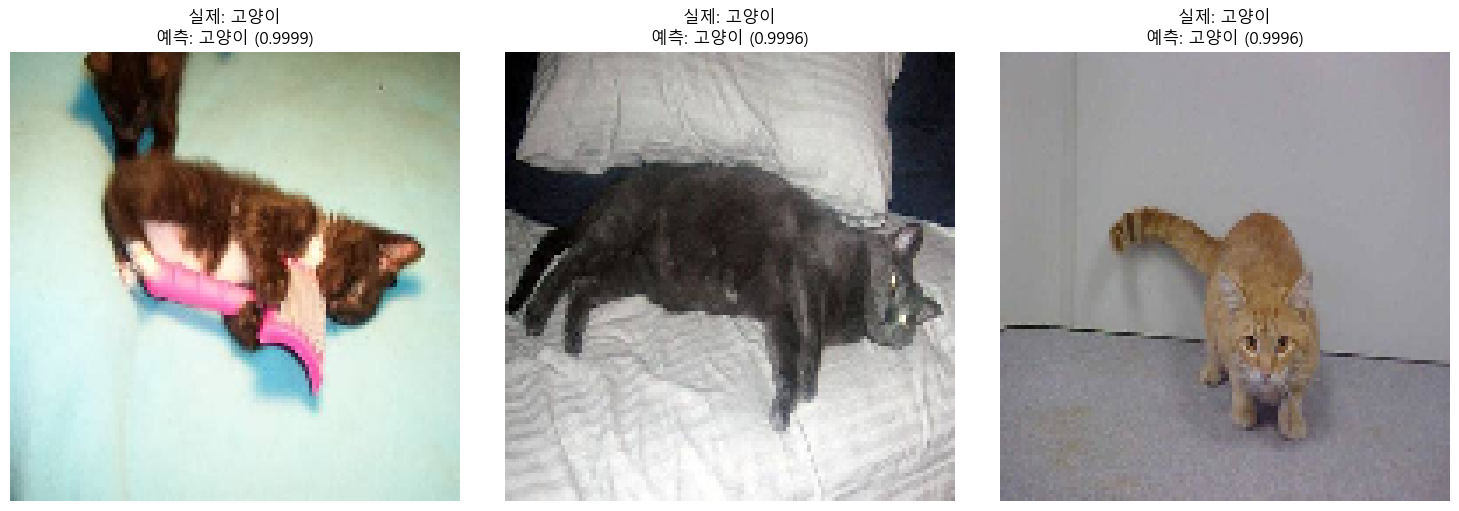

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


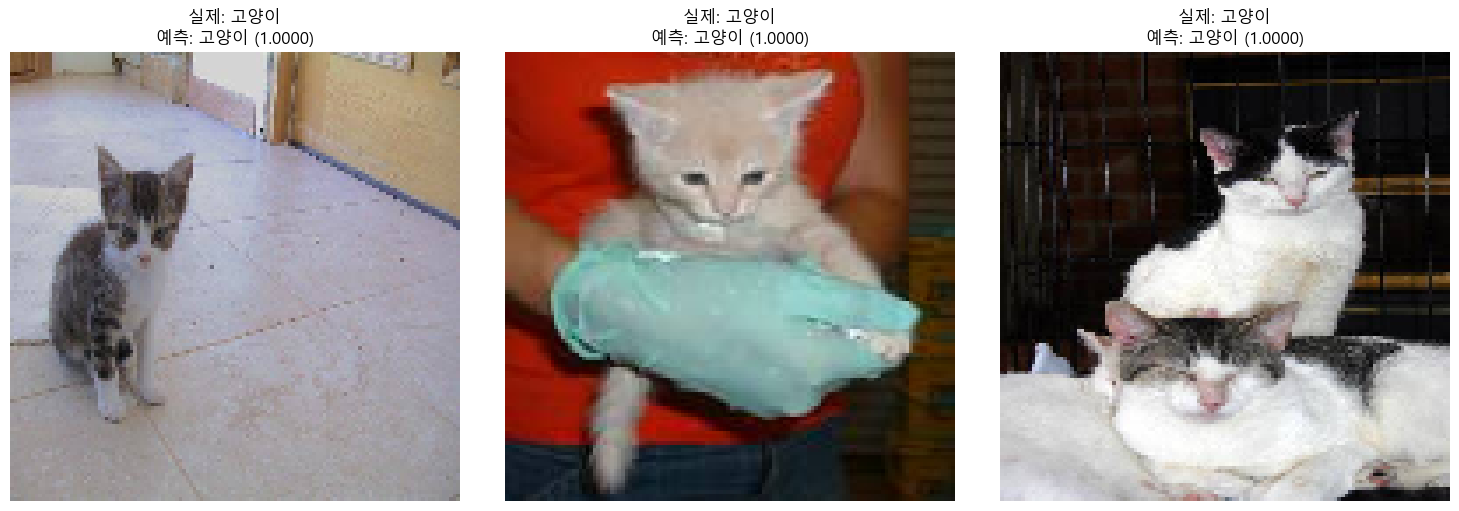

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


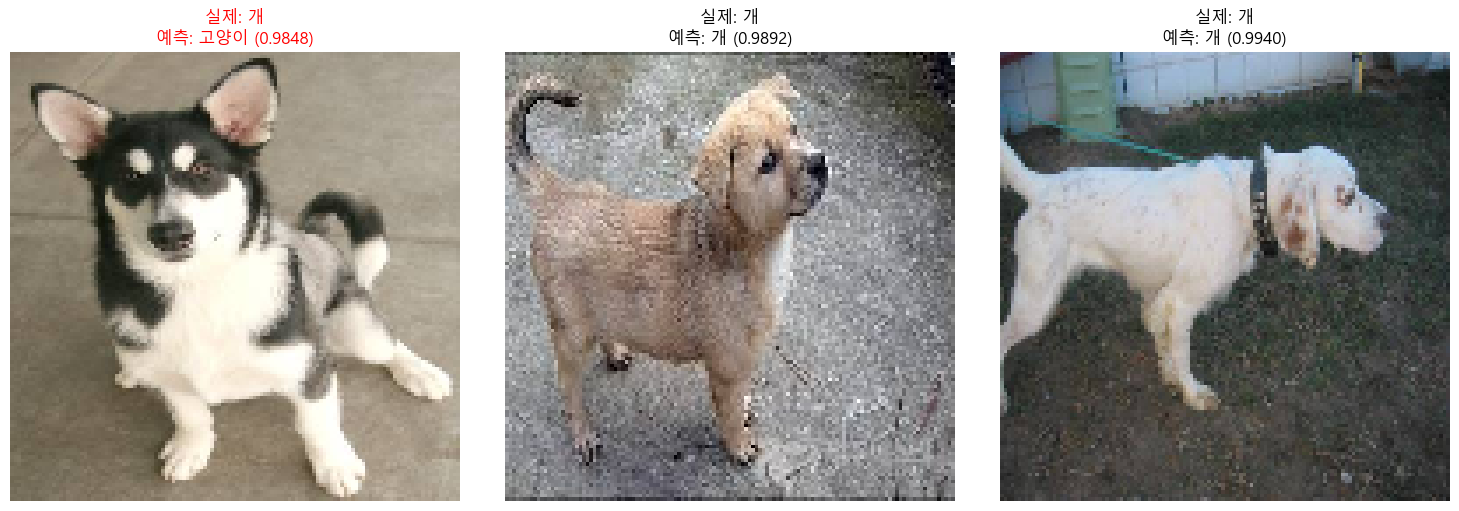

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


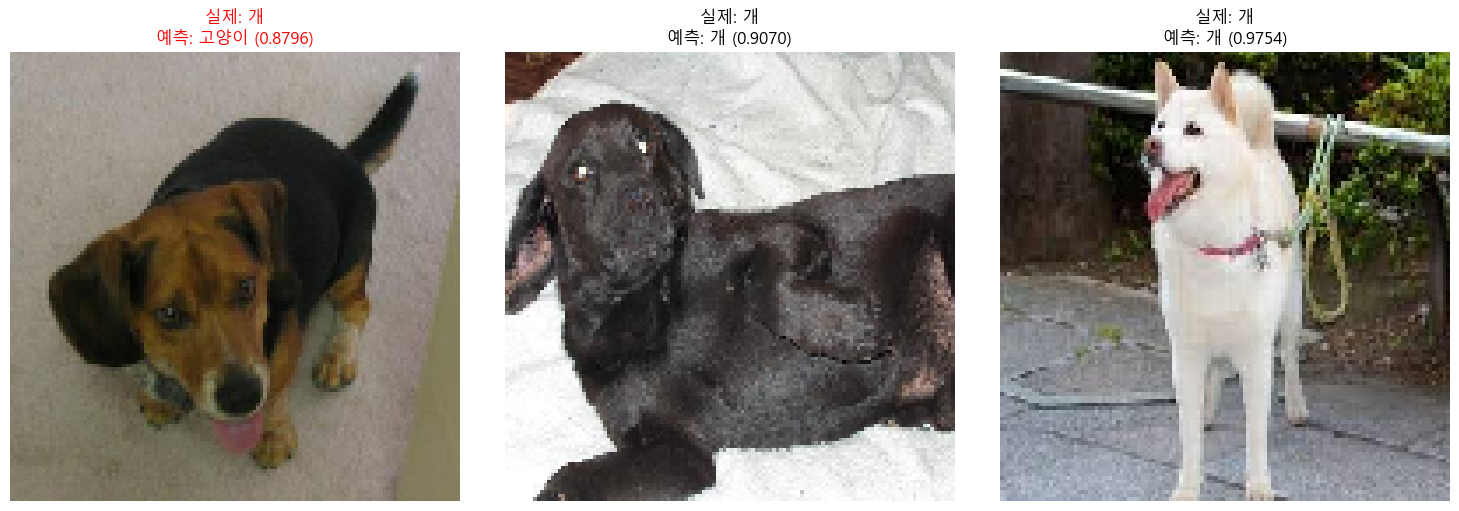

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


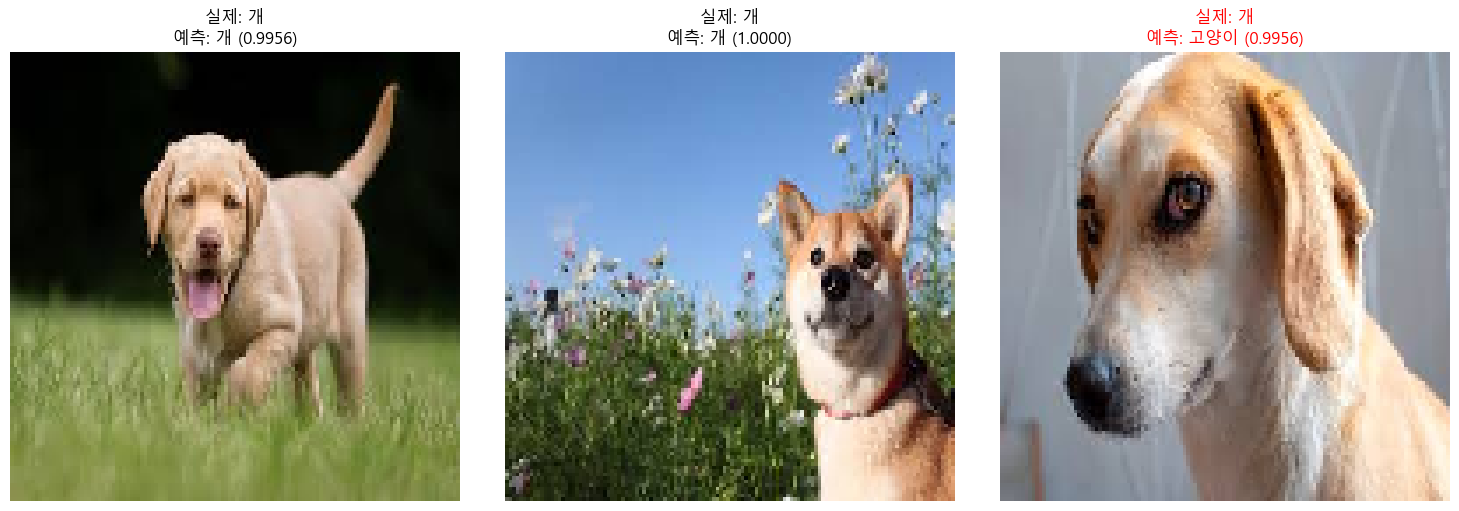

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


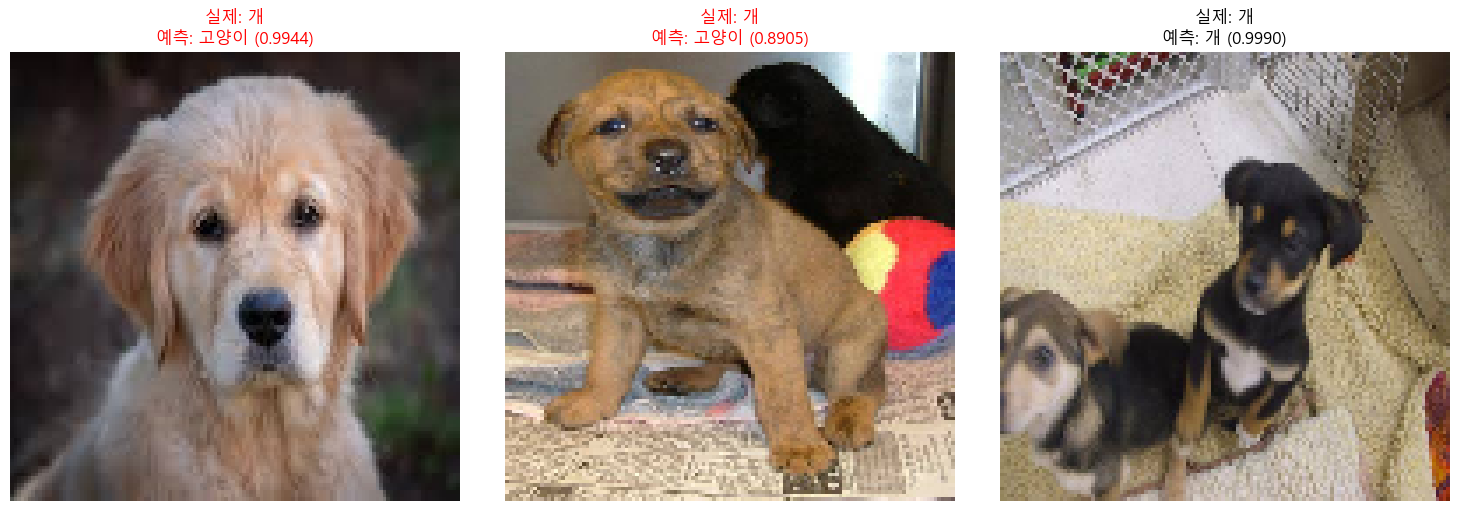

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


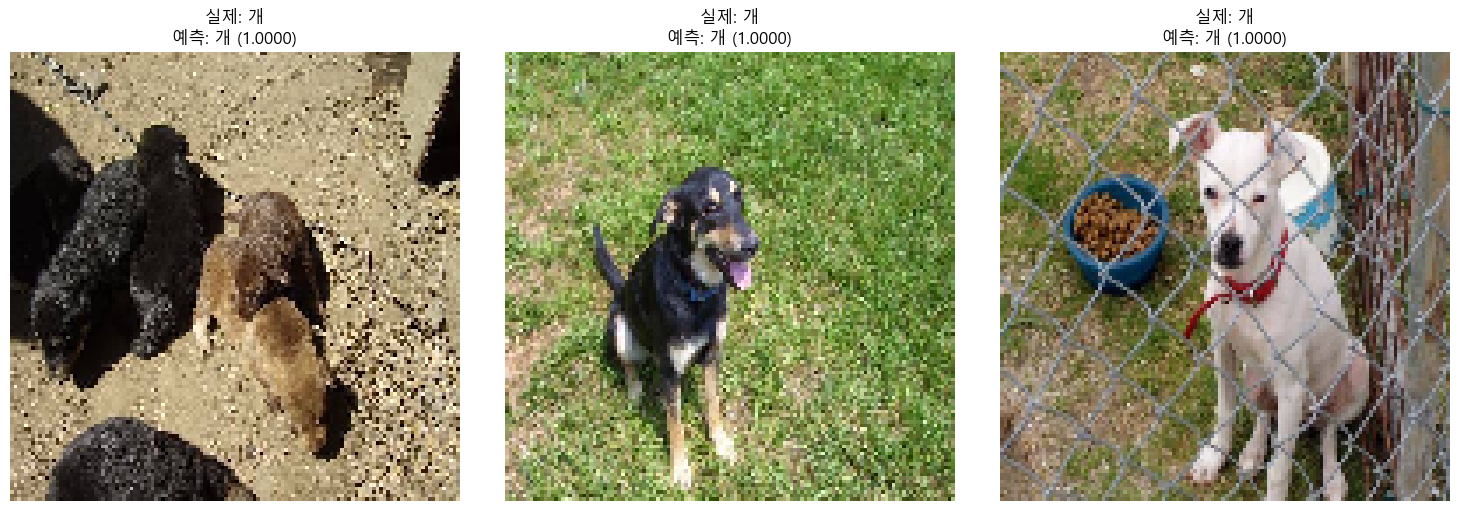

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


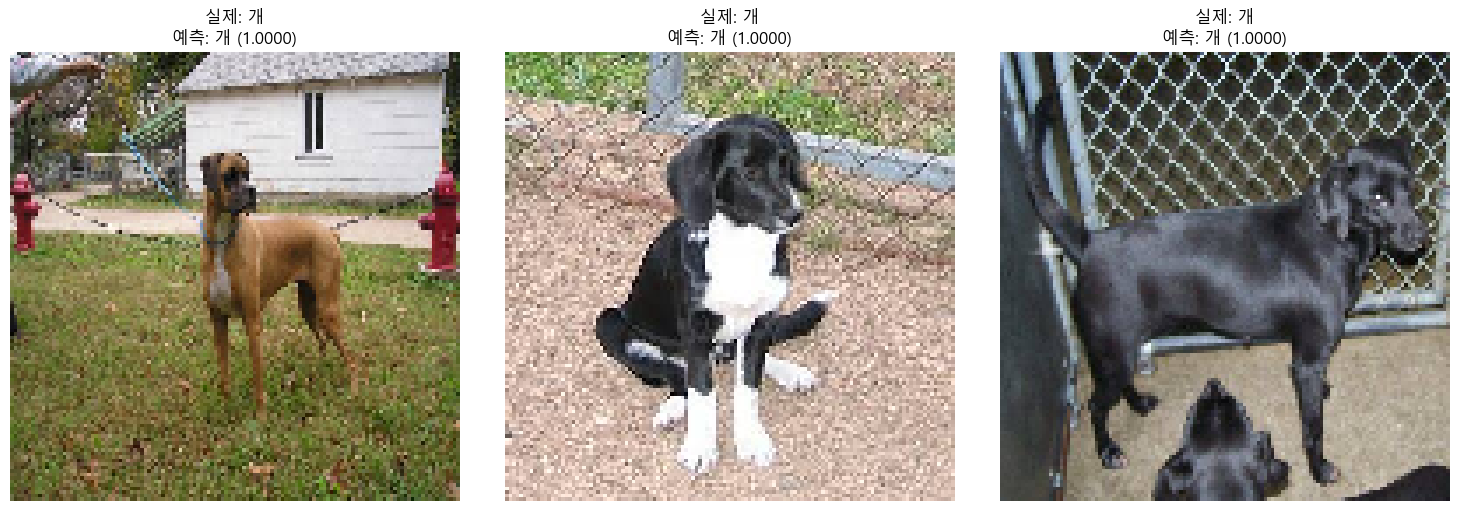

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


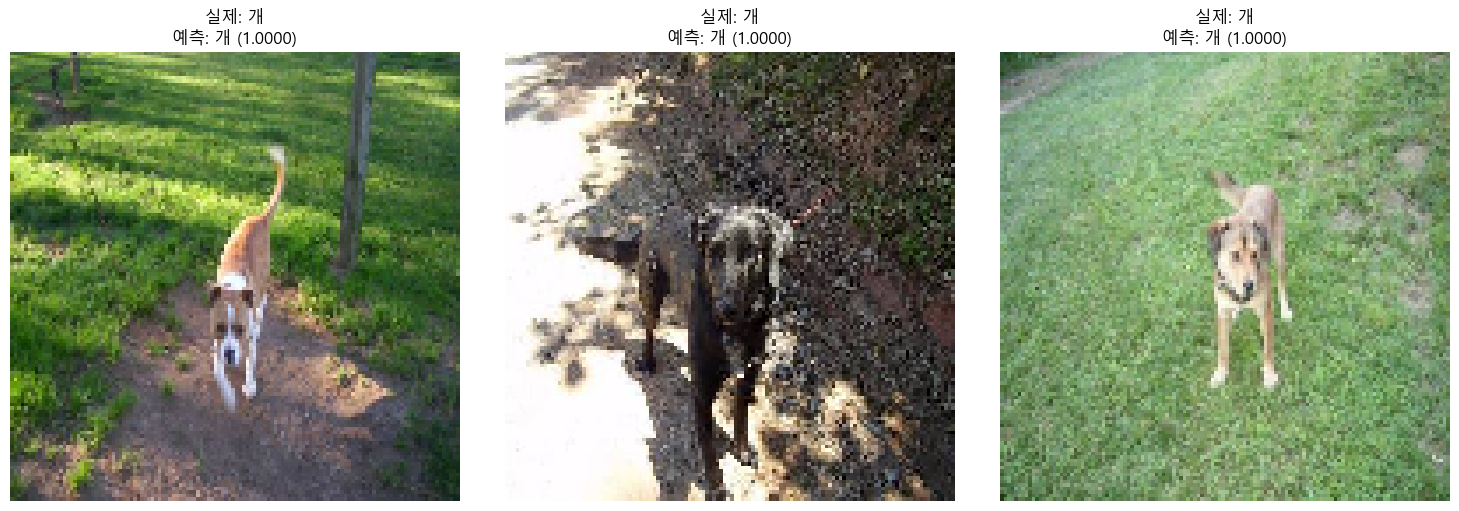

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


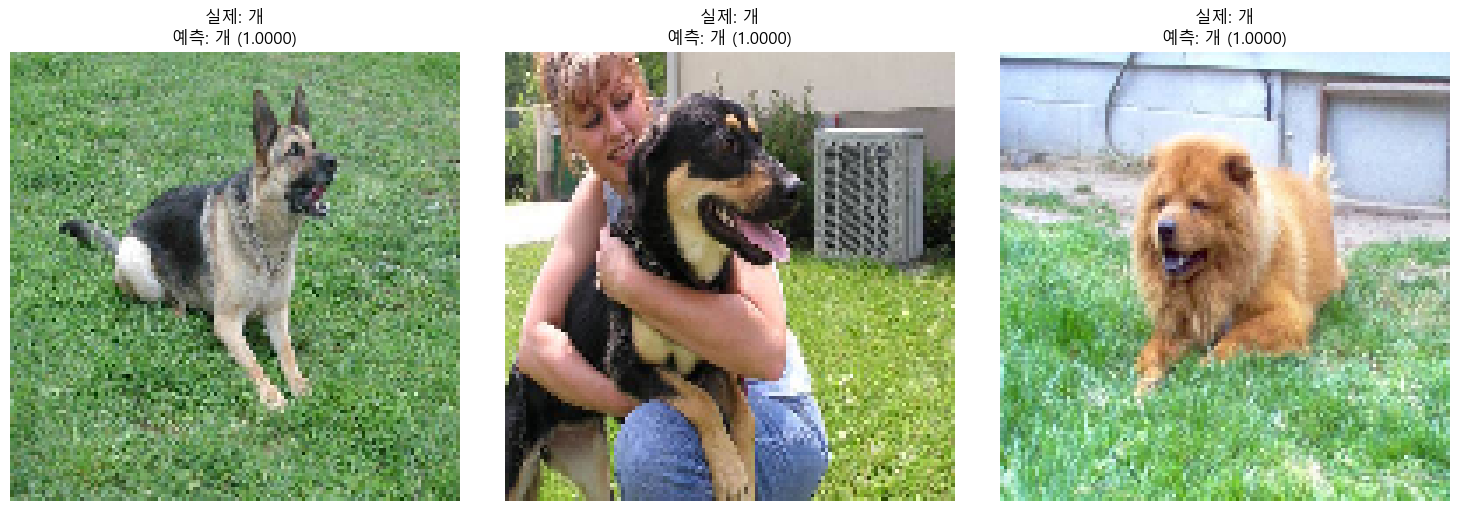

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


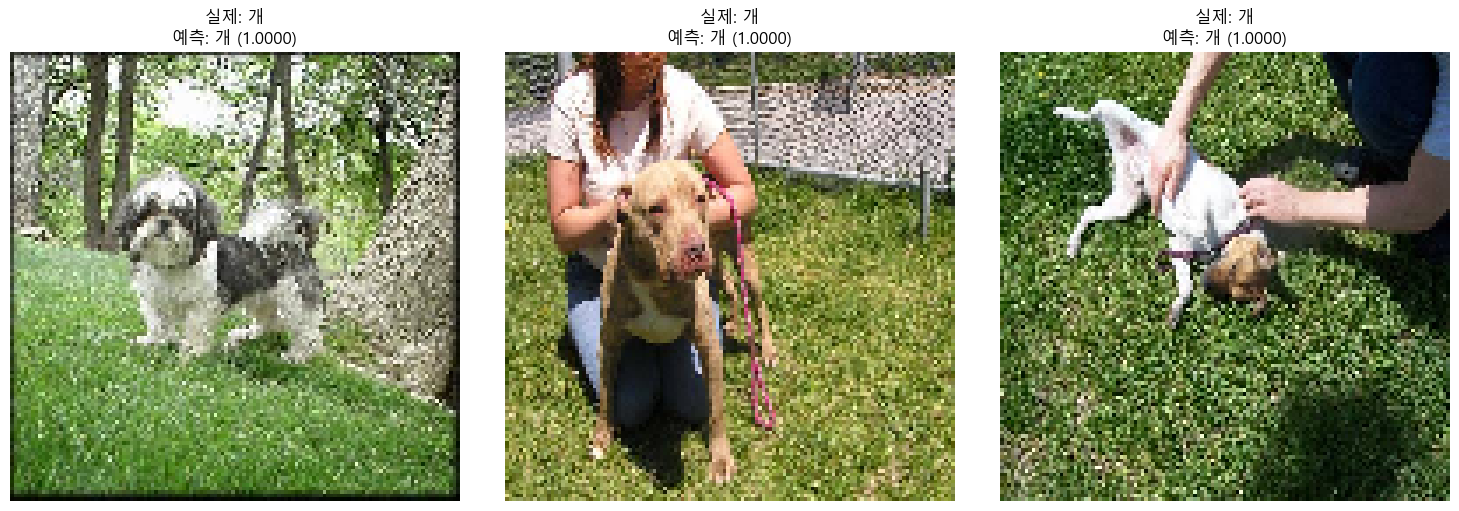

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


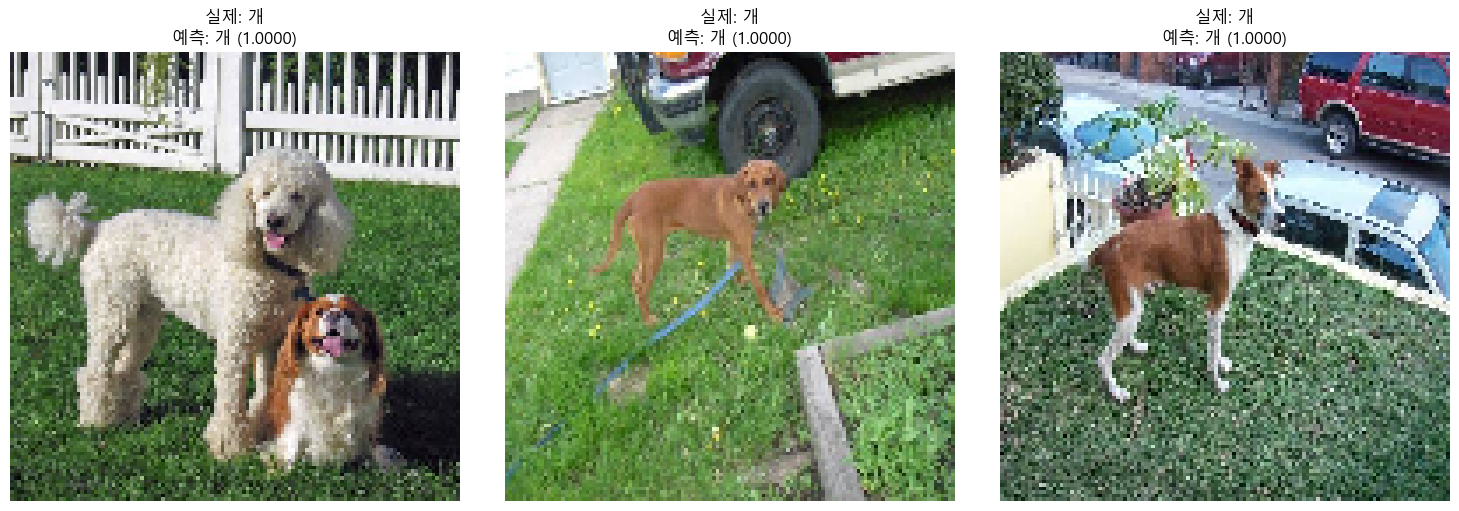


* 전체 정확도: 53/60 = 88.33%


In [8]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
import os

import matplotlib.font_manager as fm
# 한글 폰트 설정 (Windows 사용자용)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

cls_index = ['고양이', '개']
test_num = []

rootPath = 'E:/AIWork/Data/dogvscat/test'

# 고양이 이미지 불러오기
cat_folder = os.path.join(rootPath, 'cat')
for fname in os.listdir(cat_folder):
    if fname.lower().endswith('.jpg'):
        fpath = os.path.join(cat_folder, fname)
        img = image.load_img(fpath, target_size=(128, 128))
        test_num.append((img, 0))  # 0: 고양이

# 개 이미지 불러오기
dog_folder = os.path.join(rootPath, 'dog')
for fname in os.listdir(dog_folder):
    if fname.lower().endswith('.jpg'):
        fpath = os.path.join(dog_folder, fname)
        img = image.load_img(fpath, target_size=(128, 128))
        test_num.append((img, 1))  # 1: 개

# 예측 및 정확도 계산
correct = 0
cols = 3

for idx in range(0, len(test_num), cols):
    batch = test_num[idx:idx + cols]
    fig, axes = plt.subplots(1, len(batch), figsize=(15, 5))

    if len(batch) == 1:
        axes = [axes]

    for i, (img, true_label) in enumerate(batch):
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        result = model.predict(img_array)[0][0]
        pred_label = 1 if result >= 0.5 else 0
        pred_name = '개' if pred_label == 1 else '고양이'
        prob = result if pred_label == 1 else 1 - result
        true_name = '고양이' if true_label == 0 else '개'

        # 정확도 집계
        is_correct = (pred_label == true_label)
        if is_correct:
            correct += 1

        # 이미지 출력
        axes[i].imshow(img)
        axes[i].axis('off')
        title_color = 'black' if is_correct else 'red'
        axes[i].set_title(f"실제: {true_name}\n예측: {pred_name} ({prob:.4f})", fontsize=12, color=title_color)

    plt.tight_layout()
    plt.show()

# 전체 정확도 출력
accuracy = correct / len(test_num) * 100
print(f"\n* 전체 정확도: {correct}/{len(test_num)} = {accuracy:.2f}%")


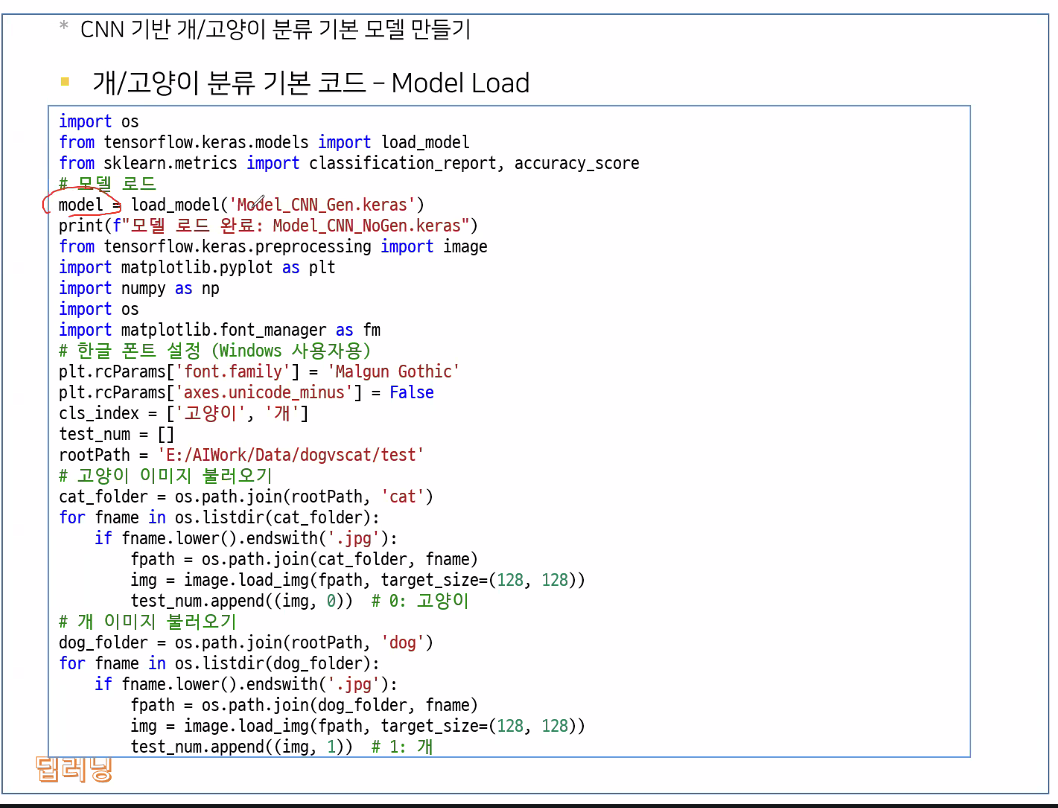